In [ ]:
import os
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
RUN = "run7"  # folder name inside runs_backup/
runs_dir = os.path.normpath(os.path.join(os.getcwd(), "..", "..", "runs_backup", RUN, "runs"))
ea = EventAccumulator(runs_dir)
ea.Reload()

# Get P1_stuck values — stuck=0 means finished
p1_stuck = ea.Scalars("episode/P1_stuck")
p2_stuck = ea.Scalars("episode/P2_stuck")

p1_finishes = sum(1 for s in p1_stuck if s.value == 0)
p2_finishes = sum(1 for s in p2_stuck if s.value == 0)

print(f"P1 finishes: {p1_finishes}")
print(f"P2 finishes: {p2_finishes}")
print(f"Total episodes with at least one finish: {sum(1 for p1, p2 in zip(p1_stuck, p2_stuck) if p1.value == 0 or p2.value == 0)}")

P1 finishes: 0
P2 finishes: 0
Total episodes with at least one finish: 0


In [ ]:
"""
Stitched view — reads every event file in runs_backup/run7/runs/ independently,
detects step resets, and concatenates them into one continuous series.
"""
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

matplotlib.rcParams['figure.figsize'] = (14, 4)
matplotlib.rcParams['figure.facecolor'] = '#0f0f23'
matplotlib.rcParams['axes.facecolor']   = '#1a1a2e'
matplotlib.rcParams['axes.edgecolor']   = 'white'
matplotlib.rcParams['xtick.color']      = 'white'
matplotlib.rcParams['ytick.color']      = 'white'
matplotlib.rcParams['text.color']       = 'white'

PROJECT_ROOT = os.path.normpath(os.path.join(os.getcwd(), "..", ".."))
RUNS_DIR     = os.path.join(PROJECT_ROOT, "runs_backup", "run7", "runs")

# Collect all root-level event files sorted by creation time
event_files = sorted(
    glob.glob(os.path.join(RUNS_DIR, "events.out.tfevents.*")),
    key=os.path.getmtime
)
print(f"Found {len(event_files)} event files")

def load_scalar(event_file, tag):
    """Load a single scalar tag from one event file."""
    ea = EventAccumulator(event_file, size_guidance={"scalars": 0})
    ea.Reload()
    try:
        return [(s.step, s.value) for s in ea.Scalars(tag)]
    except KeyError:
        return []

def stitch(event_files, tag):
    """
    Load tag from each file and stitch into one continuous series.
    If a file's first step < last stitched step, offset it to continue.
    """
    all_steps, all_vals = [], []
    offset = 0
    for f in event_files:
        data = load_scalar(f, tag)
        if not data:
            continue
        steps, vals = zip(*data)
        # If this file restarts (first step <= last stitched step), continue from offset
        if all_steps and steps[0] <= all_steps[-1]:
            offset = all_steps[-1]
        adjusted = [s + offset for s in steps]
        all_steps.extend(adjusted)
        all_vals.extend(vals)
    return np.array(all_steps), np.array(all_vals)

tags = [
    ("episode/P1_reward",      "P1 Reward",       "#00E5FF"),
    ("episode/P1_stuck",       "P1 Stuck",        "#FF6B6B"),
    ("episode/P1_progress",    "P1 Progress",     "#FFD700"),
]

fig, axes = plt.subplots(1, len(tags), figsize=(16, 4))
fig.patch.set_facecolor('#0f0f23')

for ax, (tag, label, color) in zip(axes, tags):
    steps, vals = stitch(event_files, tag)
    if len(steps) == 0:
        ax.set_title(f"{label}\n(no data)", color='white')
        continue
    # Smooth with rolling mean
    window = max(1, len(vals) // 200)
    smoothed = np.convolve(vals, np.ones(window)/window, mode='valid')
    smooth_steps = steps[:len(smoothed)]
    ax.plot(smooth_steps, smoothed, color=color, linewidth=1.2, alpha=0.9)
    ax.set_title(f"{label}  (n={len(steps)})", color='white')
    ax.set_xlabel("Episode", color='white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_color('white')

plt.suptitle("Run 7 — Full Training History (all event files stitched)", color='white', y=1.02)
plt.tight_layout()
plt.show()
print(f"Total stitched episodes (P1 reward): {len(stitch(event_files, 'episode/P1_reward')[0])}")

In [20]:
p1_rewards = ea.Scalars("episode/P1_reward")
best_p1 = max(p1_rewards, key=lambda s: s.value)
print(f"Best P1 episode: {best_p1.step} with reward {best_p1.value:.2f}")

Best P1 episode: 295 with reward 4.32


In [21]:
last_100 = [s.value for s in p1_rewards[-100:]]
print(f"P1 average reward last 100 episodes: {sum(last_100)/len(last_100):.2f}")

P1 average reward last 100 episodes: -12.76


In [22]:
action_totals = {}
for tag in ea.Tags()["scalars"]:
    if tag.startswith("actions/P1_"):
        name = tag.replace("actions/P1_", "")
        total = sum(s.value for s in ea.Scalars(tag))
        action_totals[name] = total

for action, count in sorted(action_totals.items(), key=lambda x: -x[1]):
    print(f"{action}: {int(count)}")

accel_right: 71025
drift_hard_left: 42281
wheelie_left: 33626
drift_hard_right: 30352
brake_right: 29270
brake_left: 28509
wheelie_right: 25721
drift_center: 25433
accel_center: 25005
accel_left: 23736
wheelie_center: 23019
brake_center: 21582
nothing: 21582
drift_soft_left: 20226
drift_soft_right: 16253


In [23]:
import numpy as np
stuck_values = [s.value for s in p1_stuck]
window = 500
rolling = [1 - np.mean(stuck_values[i:i+window]) for i in range(len(stuck_values)-window)]
print(f"Finish rate first 500 episodes: {rolling[0]:.1%}")
print(f"Finish rate last 500 episodes: {rolling[-1]:.1%}")

Finish rate first 500 episodes: 0.0%
Finish rate last 500 episodes: 0.0%


In [24]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from datetime import timedelta
import numpy as np

ea = EventAccumulator(runs_dir)
ea.Reload()

scalars = ea.Scalars("train/loss")
p1_stuck = ea.Scalars("episode/P1_stuck")
p1_progress = ea.Scalars("episode/P1_progress")

# Training time
times = [s.wall_time for s in scalars]
gaps = np.diff(times)
BREAK_THRESHOLD = 300
compute_gaps = gaps[gaps < BREAK_THRESHOLD]
compute_time = timedelta(seconds=float(compute_gaps.sum()))
print(f"Estimated compute time: {compute_time}")
#amount of episodes
total_episodes = len(p1_stuck)
print(f"Total episodes: {total_episodes}")
#aomount of breaks and average break time
breaks = gaps[gaps >= BREAK_THRESHOLD]
print(f"Number of breaks: {len(breaks)}")

Estimated compute time: 7:03:22.830637
Total episodes: 886
Number of breaks: 0


In [25]:
# Save state analysis
finished_episodes = [(s.step, p.value) for s, p in zip(p1_stuck, p1_progress) if s.value == 0]
early_start = [(ep, prog) for ep, prog in finished_episodes if prog > 2.5]
mid_start = [(ep, prog) for ep, prog in finished_episodes if 1.5 < prog <= 2.5]
late_start = [(ep, prog) for ep, prog in finished_episodes if prog <= 1.5]
print(f"Started near beginning (progress >2.5): {len(early_start)}")
print(f"Started mid-track (1.5-2.5): {len(mid_start)}")
print(f"Started late (progress <1.5): {len(late_start)}")

Started near beginning (progress >2.5): 0
Started mid-track (1.5-2.5): 0
Started late (progress <1.5): 0


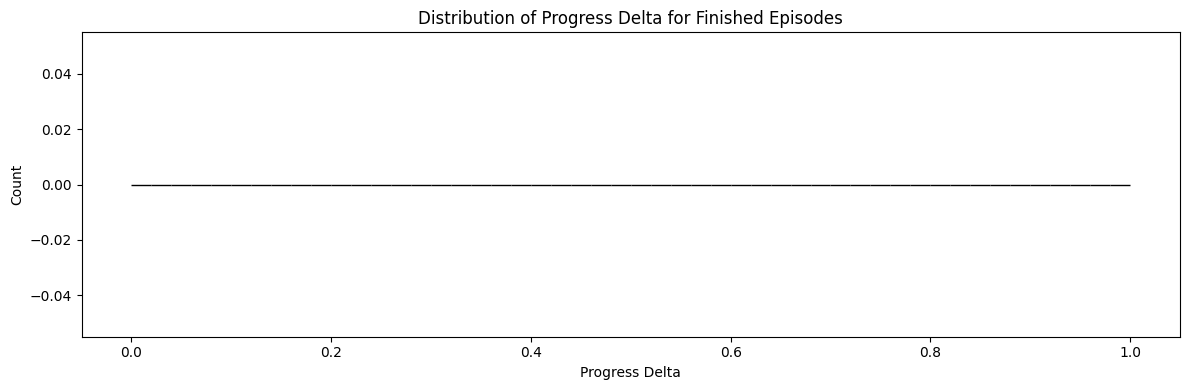

In [26]:
import matplotlib.pyplot as plt

finished_progress = [prog for _, prog in finished_episodes]

plt.figure(figsize=(12, 4))
plt.hist(finished_progress, bins=50, color='#00E5FF', edgecolor='black')
plt.xlabel('Progress Delta')
plt.ylabel('Count')
plt.title('Distribution of Progress Delta for Finished Episodes')
plt.tight_layout()
plt.show()

# Also print the distinct clusters
import numpy as np
rounded = [round(p, 1) for p in finished_progress]
from collections import Counter
for val, count in sorted(Counter(rounded).items()):
    print(f"Progress ~{val}: {count} episodes")

In [28]:
p1_rewards = ea.Scalars("episode/P1_reward")

# Match rewards to progress clusters for finished episodes
def get_cluster(progress):
    if progress < 2.2:
        return "~2.1 (latest start)"
    elif progress < 2.4:
        return "~2.3"
    elif progress < 2.55:
        return "~2.5"
    elif progress < 2.7:
        return "~2.6"
    elif progress < 2.9:
        return "~2.8"
    else:
        return "~3.1 (earliest start)"

# Build step->reward lookup
reward_by_step = {s.step: s.value for s in p1_rewards}

# Cross reference
from collections import defaultdict
cluster_rewards = defaultdict(list)

for step, prog in finished_episodes:
    if step in reward_by_step:
        cluster = get_cluster(prog)
        cluster_rewards[cluster].append(reward_by_step[step])

for cluster, rewards in sorted(cluster_rewards.items()):
    print(f"{cluster}: avg={sum(rewards)/len(rewards):.1f} min={min(rewards):.1f} max={max(rewards):.1f} n={len(rewards)}")
    